In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargamos la base de datos
data = pd.read_csv('Citas_Digital_Filtrado.csv')

# Mostramos la base
data

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,0.9,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,0.4,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,0.9,0.0,0.0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,0.9,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,NaN,Activo,0.8,1.0,1.0,0.0,Pedro Antonio,NaN,NaN,NaN,NaN,NaN,NaN
672,Ignacio,2026-07-22,Zaira Macip,NaN,Activo,0.5,0.0,0.0,0.0,Aurelio,NaN,NaN,NaN,NaN,NaN,NaN
673,Ignacio,2026-07-27,Julio Hernandez,NaN,Activo,0.5,1.0,0.0,0.0,Victor,NaN,NaN,NaN,NaN,NaN,NaN
674,Ignacio,2026-07-24,Xhunaxhi Vicente,NaN,Activo,1,1.0,1.0,1.0,Ignacio,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Revisamos la información general del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       660 non-null    str    
 1   Fecha                                     75 non-null     str    
 2   Nombre Cliente                            655 non-null    str    
 3   Telefono                                  2 non-null      str    
 4   Estatus de Lead                           641 non-null    str    
 5   Potencial de compra                       602 non-null    str    
 6   PDM                                       675 non-null    float64
 7   SDC                                       674 non-null    float64
 8   Venta                                     671 non-null    float64
 9   Asesor Asignado                           644 non-null    str    
 10  ¿Por que no ha visitado la agencia?       493 non

In [5]:
# Revisamos si existen valores nulos
valores_nulos = data.isnull().sum()

valores_nulos

BDC                                          16
Fecha                                       601
Nombre Cliente                               21
Telefono                                    674
Estatus de Lead                              35
Potencial de compra                          74
PDM                                           1
SDC                                           2
Venta                                         5
Asesor Asignado                              32
¿Por que no ha visitado la agencia?         183
¿Por que no hay solicitud de credito?       297
¿Por que no hubo prueba de manejo ?         321
¿Por que no hubo proceso wow?               312
¿Por que se asigno antes de vistar piso?    323
Unnamed: 15                                 660
dtype: int64

In [6]:
# Identificamos las columnas cuantitativas o numéricas
columnas_cuantitativas = data.select_dtypes(include=np.number).columns.tolist()

columnas_cuantitativas

['PDM', 'SDC', 'Venta']

In [7]:
# Realizamos una copia de nuestra base de datos
data1 = data.copy()

In [8]:
# Sustituimos los valores nulos de las variables cuantitativas
# utilizando la mediana

data1[columnas_cuantitativas] = data1[columnas_cuantitativas].fillna(
    data1[columnas_cuantitativas].median()
)

In [9]:
# Comprobamos nuevamente los valores nulos
data1[columnas_cuantitativas].isnull().sum()

PDM      0
SDC      0
Venta    0
dtype: int64

In [10]:
# Separamos las variables cuantitativas
cuantitativas = data1[columnas_cuantitativas]

cuantitativas

,PDM,SDC,Venta
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0
...,...,...,...
671,1.0,1.0,0.0
672,0.0,0.0,0.0
673,1.0,0.0,0.0
674,1.0,1.0,1.0


In [11]:
# Separamos las variables cualitativas
cualitativas = data1.drop(columns=columnas_cuantitativas)

cualitativas

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,0.9,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,0.4,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,0.85,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,0.9,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,0.9,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,NaN,Activo,0.8,Pedro Antonio,NaN,NaN,NaN,NaN,NaN,NaN
672,Ignacio,2026-07-22,Zaira Macip,NaN,Activo,0.5,Aurelio,NaN,NaN,NaN,NaN,NaN,NaN
673,Ignacio,2026-07-27,Julio Hernandez,NaN,Activo,0.5,Victor,NaN,NaN,NaN,NaN,NaN,NaN
674,Ignacio,2026-07-24,Xhunaxhi Vicente,NaN,Activo,1,Ignacio,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3268825781.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


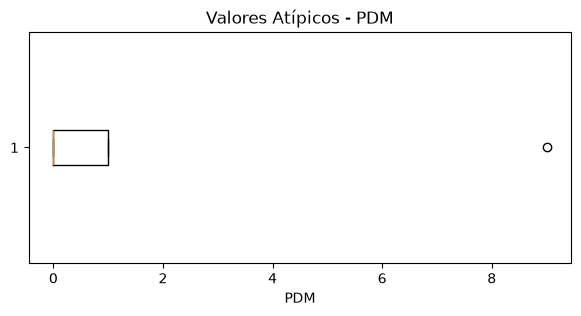

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3268825781.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


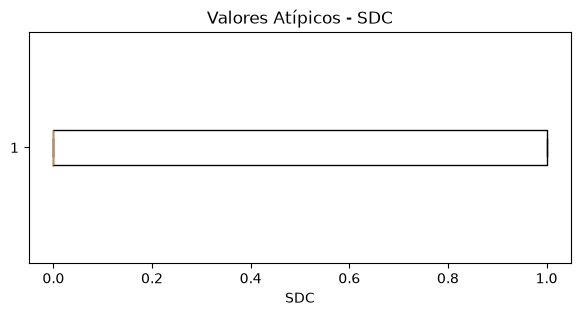

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3268825781.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


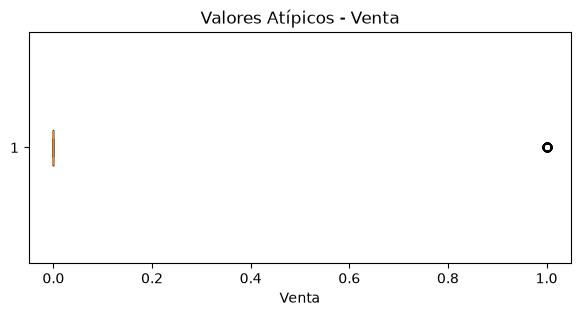

In [12]:
# Realizamos diagramas de caja para identificar valores atípicos

for columna in cuantitativas.columns:

    plt.figure(figsize=(7,3))

    plt.boxplot(
        cuantitativas[columna].dropna(),
        vert=False
    )

    plt.title("Valores Atípicos - " + columna)

    plt.xlabel(columna)

    plt.show()

# Método 1: Desviación Estándar

Se identificarán como valores atípicos aquellos datos que se encuentren fuera de la media ± 3 desviaciones estándar.

In [13]:
# Aplicamos el método de Desviación Estándar

y = cuantitativas

Limite_Superior = y.mean() + 3 * y.std()

Limite_Inferior = y.mean() - 3 * y.std()

In [14]:
# Mostramos el límite superior
print("Límite Superior:")

print(Limite_Superior)

Límite Superior:
PDM      2.294051
SDC      1.867428
Venta    0.926621
dtype: float64


In [15]:
# Mostramos el límite inferior
print("Límite Inferior:")

print(Limite_Inferior)

Límite Inferior:
PDM     -1.291092
SDC     -1.071570
Venta   -0.755024
dtype: float64


In [16]:
# Los valores que se encuentren fuera de los límites
# serán considerados valores atípicos

data3 = cuantitativas[
    (y <= Limite_Superior) &
    (y >= Limite_Inferior)
]

data3

,PDM,SDC,Venta
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,NaN
4,1.0,0.0,0.0
...,...,...,...
671,1.0,1.0,0.0
672,0.0,0.0,0.0
673,1.0,0.0,0.0
674,1.0,1.0,NaN


In [17]:
# Contamos los valores atípicos encontrados

outliers_desviacion = data3.isnull().sum()

print("Valores atípicos encontrados:")

outliers_desviacion

Valores atípicos encontrados:


PDM       1
SDC       0
Venta    58
dtype: int64

In [18]:
# Realizamos una copia del DataFrame

data_clean_std = data3.copy()

In [19]:
# Sustituimos los valores atípicos utilizando la media

data_clean_std = data_clean_std.fillna(
    round(data3.mean(), 1)
)

data_clean_std

,PDM,SDC,Venta
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
671,1.0,1.0,0.0
672,0.0,0.0,0.0
673,1.0,0.0,0.0
674,1.0,1.0,0.0


In [20]:
# Unimos las variables cualitativas
# con las variables cuantitativas ya tratadas

Datos_limpios_std = pd.concat(
    [cualitativas, data_clean_std],
    axis=1
)

In [21]:
# Recuperamos el orden original de las columnas

Datos_limpios_std = Datos_limpios_std[data.columns]

Datos_limpios_std

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,0.9,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,0.4,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,0.9,0.0,0.0,0.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,0.9,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,NaN,Activo,0.8,1.0,1.0,0.0,Pedro Antonio,NaN,NaN,NaN,NaN,NaN,NaN
672,Ignacio,2026-07-22,Zaira Macip,NaN,Activo,0.5,0.0,0.0,0.0,Aurelio,NaN,NaN,NaN,NaN,NaN,NaN
673,Ignacio,2026-07-27,Julio Hernandez,NaN,Activo,0.5,1.0,0.0,0.0,Victor,NaN,NaN,NaN,NaN,NaN,NaN
674,Ignacio,2026-07-24,Xhunaxhi Vicente,NaN,Activo,1,1.0,1.0,0.0,Ignacio,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Comprobamos que no existan valores nulos
# en las variables cuantitativas

Datos_limpios_std[columnas_cuantitativas].isnull().sum()

PDM      0
SDC      0
Venta    0
dtype: int64

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3841518328.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


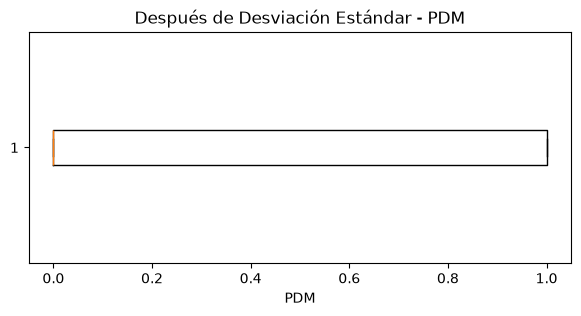

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3841518328.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


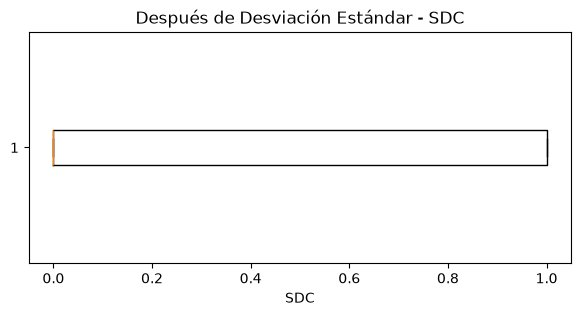

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/3841518328.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


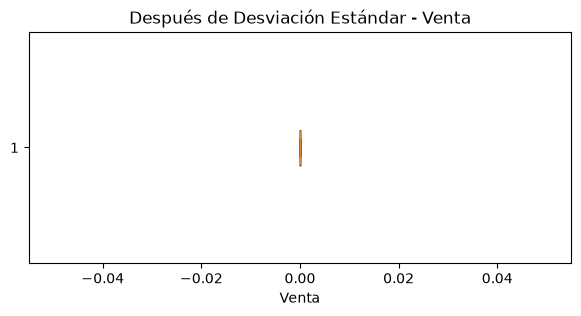

In [23]:
# Diagramas de caja después de aplicar
# el método de Desviación Estándar

for columna in columnas_cuantitativas:

    plt.figure(figsize=(7,3))

    plt.boxplot(
        Datos_limpios_std[columna].dropna(),
        vert=False
    )

    plt.title(
        "Después de Desviación Estándar - " + columna
    )

    plt.xlabel(columna)

    plt.show()

In [24]:
# Guardamos el resultado del método
# de Desviación Estándar en un archivo CSV

Datos_limpios_std.to_csv(
    "Citas_Digital_Desviacion_Estandar.csv",
    index=False
)

# Método 2: Rango Intercuartílico (IQR)

El método del Rango Intercuartílico utiliza el primer cuartil (Q1) y el tercer cuartil (Q3) para identificar los valores atípicos.

Límite inferior = Q1 - 1.5 × IQR

Límite superior = Q3 + 1.5 × IQR

In [25]:
# Aplicamos el método de Rango Intercuartílico

y = cuantitativas

# Primer cuartil
percentile25 = y.quantile(0.25)

# Tercer cuartil
percentile75 = y.quantile(0.75)

# Rango Intercuartílico
iqr = percentile75 - percentile25

In [26]:
# Mostramos Q1

print("Primer Cuartil Q1:")

print(percentile25)

Primer Cuartil Q1:
PDM      0.0
SDC      0.0
Venta    0.0
Name: 0.25, dtype: float64


In [27]:
# Mostramos Q3

print("Tercer Cuartil Q3:")

print(percentile75)

Tercer Cuartil Q3:
PDM      1.0
SDC      1.0
Venta    0.0
Name: 0.75, dtype: float64


In [28]:
# Mostramos el Rango Intercuartílico

print("Rango Intercuartílico:")

print(iqr)

Rango Intercuartílico:
PDM      1.0
SDC      1.0
Venta    0.0
dtype: float64


In [29]:
# Calculamos el límite superior

Limite_Superior_iqr = percentile75 + 1.5 * iqr

In [30]:
# Calculamos el límite inferior

Limite_Inferior_iqr = percentile25 - 1.5 * iqr

In [31]:
print("Límite Superior:")

print(Limite_Superior_iqr)

print("\nLímite Inferior:")

print(Limite_Inferior_iqr)

Límite Superior:
PDM      2.5
SDC      2.5
Venta    0.0
dtype: float64

Límite Inferior:
PDM     -1.5
SDC     -1.5
Venta    0.0
dtype: float64


In [32]:
# Detectamos los valores que se encuentran
# fuera de los límites permitidos

data3_iqr = cuantitativas[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

data3_iqr

,PDM,SDC,Venta
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,NaN
4,1.0,0.0,0.0
...,...,...,...
671,1.0,1.0,0.0
672,0.0,0.0,0.0
673,1.0,0.0,0.0
674,1.0,1.0,NaN


In [33]:
# Contamos los valores atípicos

outliers_iqr = data3_iqr.isnull().sum()

print("Valores atípicos encontrados mediante IQR:")

outliers_iqr

Valores atípicos encontrados mediante IQR:


PDM       1
SDC       0
Venta    58
dtype: int64

In [34]:
# Realizamos una copia del DataFrame

data4_iqr = data3_iqr.copy()

In [35]:
# Sustituimos los valores atípicos utilizando la mediana

data4_iqr = data4_iqr.fillna(
    round(data3_iqr.median(), 1)
)

data4_iqr

,PDM,SDC,Venta
0,1.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
671,1.0,1.0,0.0
672,0.0,0.0,0.0
673,1.0,0.0,0.0
674,1.0,1.0,0.0


In [36]:
# Unimos nuevamente variables cualitativas
# y cuantitativas

Datos_limpios_iqr = pd.concat(
    [cualitativas, data4_iqr],
    axis=1
)

In [37]:
# Recuperamos el orden original de las columnas

Datos_limpios_iqr = Datos_limpios_iqr[data.columns]

Datos_limpios_iqr

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,0.9,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,0.4,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,0.9,0.0,0.0,0.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,0.9,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,NaN,Activo,0.8,1.0,1.0,0.0,Pedro Antonio,NaN,NaN,NaN,NaN,NaN,NaN
672,Ignacio,2026-07-22,Zaira Macip,NaN,Activo,0.5,0.0,0.0,0.0,Aurelio,NaN,NaN,NaN,NaN,NaN,NaN
673,Ignacio,2026-07-27,Julio Hernandez,NaN,Activo,0.5,1.0,0.0,0.0,Victor,NaN,NaN,NaN,NaN,NaN,NaN
674,Ignacio,2026-07-24,Xhunaxhi Vicente,NaN,Activo,1,1.0,1.0,0.0,Ignacio,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Comprobamos que no existan valores nulos

Datos_limpios_iqr[columnas_cuantitativas].isnull().sum()

PDM      0
SDC      0
Venta    0
dtype: int64

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/155011755.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


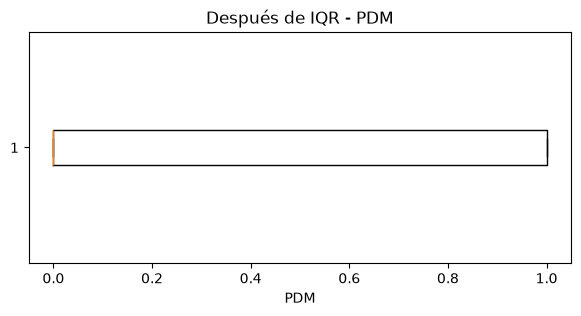

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/155011755.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


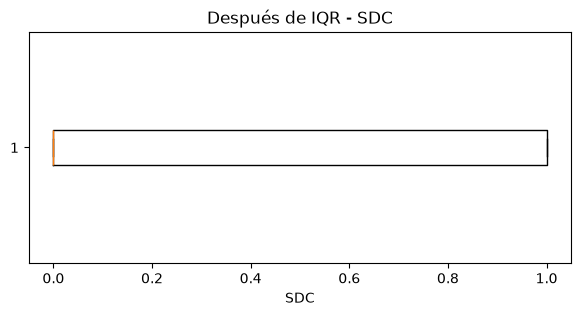

/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_91378/155011755.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


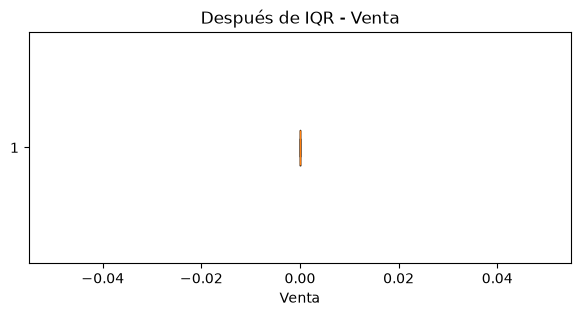

In [39]:
# Diagramas de caja después de aplicar IQR

for columna in columnas_cuantitativas:

    plt.figure(figsize=(7,3))

    plt.boxplot(
        Datos_limpios_iqr[columna].dropna(),
        vert=False
    )

    plt.title(
        "Después de IQR - " + columna
    )

    plt.xlabel(columna)

    plt.show()

In [40]:
# Guardamos el resultado del método IQR
# en un nuevo archivo CSV

Datos_limpios_iqr.to_csv(
    "Citas_Digital_IQR.csv",
    index=False
)

## Conclusión

En esta actividad se aplicaron dos métodos para identificar y tratar valores atípicos: Desviación Estándar y Rango Intercuartílico (IQR).

Mediante la Desviación Estándar se establecieron límites utilizando la media más y menos tres desviaciones estándar. Por otro lado, en el método IQR se utilizaron el primer y tercer cuartil para establecer los límites permitidos.

Posteriormente, se comprobaron los resultados mediante diagramas de caja para cada una de las variables cuantitativas y se generó un archivo CSV correspondiente a cada método.